# Region Field Heatmaps

For a given `motionmapperpy` project (UMAP embedding + watershed segmentation, e.g.
`Results/LargeBlindVisualActivity/`), this notebook computes the **mean value** of
several sensor fields &mdash; CO&#8322; (averaged over the two sensor channels),
relative humidity, activity and ambient temperature &mdash; over every watershed
region, and renders each as a heatmap painted directly onto the region map (the
same regions shown in `UMAP/zWshed*.png`, e.g. `zWshed15.png` for a 15-region run).

**Prerequisite:** the target project must already have gone through the watershed
step of `Ethogram_Generation_Metabolism.ipynb` (i.e. `UMAP/zVals_wShed_groups.mat`
must exist), and the per-dataset raw dataframes must be cached in
`Results/Intermediate_Results/*.pkl` (produced by the same notebook's dataset-loading
section). This notebook does not re-download any data or re-run PCA/UMAP/watershed
&mdash; it only reloads what that pipeline already computed and saved.

Uses the same region-alignment logic as `Ethogram_Generation_Metabolism.ipynb`
(see its "Region Timeline" section) and the watershed-artifact loader from
`umap_video_utils.py`.

Kernel: `motionmapper37` (same as `Ethogram_Generation_Metabolism.ipynb`).

## 1.&nbsp; Imports

In [1]:
import glob, os, pickle, re, sys
from pathlib import Path

sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCThermalPlots/RHCImaging')
sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCThermalPlots')
sys.path.append('Metabolism/VisualActivity/RHCVisualisation')
sys.path.append('Metabolism/VisualActivity')
sys.path.append('Metabolism')
sys.path.insert(0, os.path.abspath('motionmapperpy-master'))

import hdf5storage
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from umap_video_utils import load_watershed_artifacts
from utils import reconstruct_whole_hive
%matplotlib inline

## 2.&nbsp; Configuration

In [2]:
# Path to the motionmapperpy project directory (same one used in Ethogram_Generation_Metabolism.ipynb)
projectPath = r"/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivityWholeHive/"
intermediate_dir = "Results/Intermediate_Results"

PROJECT_DIR = Path(projectPath)
PROJECTIONS_DIR = PROJECT_DIR / "Projections"

# parameters.pkl records which method (UMAP/TSNE) and project path were used to build the
# watershed run, so we load it instead of hard-coding the method.
with open(PROJECT_DIR / "parameters.pkl", "rb") as f:
    parameters = pickle.load(f)

UMAP_DIR = PROJECT_DIR / parameters.method
WSHED_PATH = UMAP_DIR / "zVals_wShed_groups.mat"
assert WSHED_PATH.exists(), f"Watershed file not found at {WSHED_PATH}. Run the watershed step of Ethogram_Generation_Metabolism.ipynb first."
print(f"Project: {PROJECT_DIR}")
print(f"Method : {parameters.method}")
print(f"Watershed file: {WSHED_PATH}")

# pipeline_config.pkl (only saved by newer runs of Ethogram_Generation.ipynb) is the
# authoritative record of which raw columns actually fed this project's PCA/UMAP -- unlike
# Results/Intermediate_Results/*.pkl, which is a *shared*, mutable cache that different
# projects' runs (with different only_ambT/include_activity/whole_hive settings) all merge
# columns into over time, so a column being present there doesn't mean this project used it.
# Section 8 uses this, when available, to select fields instead of guessing from cache contents.
pipeline_config_path = PROJECT_DIR / "pipeline_config.pkl"
if pipeline_config_path.exists():
    with open(pipeline_config_path, "rb") as f:
        pipeline_config = pickle.load(f)
    print("\nLoaded pipeline_config.pkl -- authoritative record of this project's inputs:")
    for k, v in pipeline_config.items():
        print(f"  {k}: {v}")
else:
    pipeline_config = None
    print(
        "\nNo pipeline_config.pkl found for this project (that bookkeeping was only added to "
        "Ethogram_Generation.ipynb after this project was generated). Section 8 will fall back "
        "to inferring which fields to plot from whichever columns happen to be present in "
        "df_nat -- if in doubt about what this project's pipeline actually used, check the "
        "generating notebook's config at the relevant commit (e.g. via git history/timestamps) "
        "rather than trusting the cache."
    )

Project: /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivityWholeHive
Method : UMAP
Watershed file: /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivityWholeHive/UMAP/zVals_wShed_groups.mat

Loaded pipeline_config.pkl -- authoritative record of this project's inputs:
  used_exp_list: ['SharpDay', 'SharpNight', 'SoftDay', 'SoftNight', 'Idle', 'Constant', 'Observation']
  required_keys: [('Constant', 2), ('Idle', 1), ('Idle', 2), ('Observation', 1), ('Observation', 2), ('SharpDay', 1), ('SharpDay', 2), ('SharpNight', 1), ('SharpNight', 2), ('SoftDay', 1), ('SoftDay', 2), ('SoftNight', 1)]
  resolution: 600
  only_ambT: True
  include_temperature: False
  include_activity: True
  whole_hive: True
  WideNormalisation: True
  variance_threshold: 0.99
  min_regions: 10


## 3.&nbsp; Load per-dataset raw data

Dataset identity is taken directly from the `*_pcaModes.mat` files present in
`Projections/`, i.e. exactly the datasets that went into the current watershed run &mdash;
not from the experiment config, so this stays correct even if `used_exp_list` changes in
the source notebook. This works for both single-IHL runs (`{exp}_hive{hive_nb}_{ihl}`,
e.g. `Observation_hive1_upper`) and whole-hive runs (`{exp}_hive{hive_nb}`, both ihls
combined, e.g. `Observation_hive1`) &mdash; see `whole_hive` in
`Ethogram_Generation.ipynb`.

In [3]:
dataset_id_pattern = re.compile(r"^(?P<exp>.+)_hive(?P<hive>\d+)(?:_(?P<ihl>upper|lower))?$")


def _source_id(key):
    """Rebuild the exact string used to name this dataset's *_pcaModes.mat file.

    key is (exp, hive_nb, ihl); ihl is None for a whole-hive (both ihls combined) run --
    same convention as _source_id() in Ethogram_Generation.ipynb.
    """
    exp, hive_nb, ihl = key
    return f"{exp}_hive{hive_nb}" if ihl is None else f"{exp}_hive{hive_nb}_{ihl}"


dataset_keys = []  # list of (exp, hive_nb, ihl); ihl=None for a whole-hive dataset
for pca_file in sorted(PROJECTIONS_DIR.glob("*_pcaModes.mat")):
    source_id = pca_file.name[: -len("_pcaModes.mat")]
    m = dataset_id_pattern.match(source_id)
    if not m:
        print(f"Skipping unrecognized projection file name: {pca_file.name}")
        continue
    dataset_keys.append((m.group("exp"), int(m.group("hive")), m.group("ihl")))

print(f"Found {len(dataset_keys)} datasets in {PROJECTIONS_DIR}:")
for key in dataset_keys:
    print(" ", key, f"(source_id={_source_id(key)})")

Found 12 datasets in /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivityWholeHive/Projections:
  ('Constant', 2, None) (source_id=Constant_hive2)
  ('Idle', 1, None) (source_id=Idle_hive1)
  ('Idle', 2, None) (source_id=Idle_hive2)
  ('Observation', 1, None) (source_id=Observation_hive1)
  ('Observation', 2, None) (source_id=Observation_hive2)
  ('SharpDay', 1, None) (source_id=SharpDay_hive1)
  ('SharpDay', 2, None) (source_id=SharpDay_hive2)
  ('SharpNight', 1, None) (source_id=SharpNight_hive1)
  ('SharpNight', 2, None) (source_id=SharpNight_hive2)
  ('SoftDay', 1, None) (source_id=SoftDay_hive1)
  ('SoftDay', 2, None) (source_id=SoftDay_hive2)
  ('SoftNight', 1, None) (source_id=SoftNight_hive1)


In [4]:
exps_dfs = {}
for key in dataset_keys:
    exp, hive_nb, ihl = key
    source_id = _source_id(key)
    pkl_path = os.path.join(intermediate_dir, f"{source_id}.pkl")

    if os.path.exists(pkl_path):
        with open(pkl_path, "rb") as f:
            exps_dfs[key] = pickle.load(f)
    elif ihl is None:
        # No hive-level pickle cached directly -- if both ihls were already cached separately
        # (e.g. from an earlier single-IHL run), reconstruct the whole-hive dataset from them
        # instead, same fallback as the dataset-loading section of Ethogram_Generation.ipynb.
        upper_path = os.path.join(intermediate_dir, f"{exp}_hive{hive_nb}_upper.pkl")
        lower_path = os.path.join(intermediate_dir, f"{exp}_hive{hive_nb}_lower.pkl")
        assert os.path.exists(upper_path) and os.path.exists(lower_path), (
            f"Missing cached dataset {pkl_path}, and no {upper_path}/{lower_path} pair to "
            f"reconstruct it from. Run the dataset-loading section of Ethogram_Generation.ipynb "
            f"(with save_files=True) first."
        )
        with open(upper_path, "rb") as f:
            upper_df = pickle.load(f)
        with open(lower_path, "rb") as f:
            lower_df = pickle.load(f)

        has_temp_grid = any(re.match(r"^t\d+$", c) for c in upper_df.columns) and any(
            re.match(r"^t\d+$", c) for c in lower_df.columns
        )
        exps_dfs[key] = reconstruct_whole_hive(upper_df, lower_df, only_amb_T=not has_temp_grid)
        print(f"Reconstructed {source_id} from cached {exp}_hive{hive_nb}_upper/lower pickles.")
    else:
        raise AssertionError(
            f"Missing cached dataset {pkl_path}. Run the dataset-loading section of "
            f"Ethogram_Generation.ipynb (with save_files=True) first."
        )
    print(f"Loaded {source_id}: {exps_dfs[key].shape}")

Loaded Constant_hive2: (419, 6)
Loaded Idle_hive1: (1475, 6)
Loaded Idle_hive2: (1351, 6)
Loaded Observation_hive1: (7232, 134)
Loaded Observation_hive2: (3491, 134)
Loaded SharpDay_hive1: (1526, 6)
Loaded SharpDay_hive2: (1233, 6)
Loaded SharpNight_hive1: (1988, 6)
Loaded SharpNight_hive2: (981, 6)
Loaded SoftDay_hive1: (1871, 6)
Loaded SoftDay_hive2: (1433, 6)
Loaded SoftNight_hive1: (2193, 6)


## 4.&nbsp; Interpolate short gaps

Same gap-filling as the "Preprocessing of Data" section of `Ethogram_Generation_Metabolism.ipynb`:
linearly interpolate short NaN gaps (`limit=6` samples). Unlike before, this step no longer
determines *which rows exist* &mdash; that used to come from an additional
`dropna(how='any')` here, trusted to reproduce (by timestamp) whatever row set actually got
fed into `findEmbeddings` when this dataset's PCA/UMAP was generated. That's fragile: if the
`limit` used at generation time differed from `limit=6` (this notebook's own `limit` has
flip-flopped between 3 and 6 across commits), the reproduced row set silently diverges from
the true one. Instead, Section 5 uses each dataset's own `real_timestamps` (saved alongside
its embeddings in `Projections/{source_id}_pcaModes.mat` &mdash; the ground truth of what
`findEmbeddings` was actually fed) as the authoritative row set, and just reindexes this
interpolated dataframe onto those exact timestamps to look up feature values. The diagnostic
print below is for debugging only; it does not gate anything downstream.

In [5]:
exps_dfs_interp = {}
for key, df in exps_dfs.items():
    df = df.astype(float)
    df = df.interpolate(method='time', limit=6, limit_direction='both')
    exps_dfs_interp[key] = df

    # Diagnostic only -- no longer used to determine the row set (Section 5 uses each
    # dataset's own real_timestamps for that). A big gap between these two numbers flags
    # exactly the bug this redesign fixes: if a *different* interpolation `limit` was used
    # when this dataset's PCA/UMAP was actually generated, a dropna(how='any') here can
    # diverge (either direction) from the true row set.
    n_would_survive_dropna = len(df.dropna(how='any'))
    print(f"{key}: {len(df)} rows after interpolation ({n_would_survive_dropna} would survive a dropna(how='any'))")

('Constant', 2, None): 419 rows after interpolation (419 would survive a dropna(how='any'))
('Idle', 1, None): 1475 rows after interpolation (1475 would survive a dropna(how='any'))
('Idle', 2, None): 1351 rows after interpolation (1351 would survive a dropna(how='any'))
('Observation', 1, None): 7232 rows after interpolation (4213 would survive a dropna(how='any'))
('Observation', 2, None): 3491 rows after interpolation (2003 would survive a dropna(how='any'))
('SharpDay', 1, None): 1526 rows after interpolation (1526 would survive a dropna(how='any'))
('SharpDay', 2, None): 1233 rows after interpolation (1233 would survive a dropna(how='any'))
('SharpNight', 1, None): 1988 rows after interpolation (1988 would survive a dropna(how='any'))
('SharpNight', 2, None): 981 rows after interpolation (981 would survive a dropna(how='any'))
('SoftDay', 1, None): 1871 rows after interpolation (1871 would survive a dropna(how='any'))
('SoftDay', 2, None): 1433 rows after interpolation (1407 would

## 5.&nbsp; Build the per-point dataframe (`df_nat`)

One row per timepoint in each dataset's own `real_timestamps` (loaded from
`Projections/{source_id}_pcaModes.mat`, the same array `findEmbeddings` was run on) &mdash;
this is the authoritative row set now, not whatever `interpolate(...).dropna(...)` happens to
reproduce (see Section 4). Each dataset's interpolated dataframe is `reindex`ed onto its
`real_timestamps`; any timestamp not recoverable from the cached/interpolated raw data
becomes a row of NaN feature values rather than a dropped row (harmless &mdash;
`groupby(...).mean()` in Section 8 skips NaNs, and Section 7's region assignment only needs
the *timestamp* to succeed, not the feature values). Tagged with `source_id` and real
timestamp, same as before.

In [6]:
# real_timestamps_by_source: source_id -> full real_timestamps array (tz-aware UTC), exactly
# as saved by findEmbeddings, NOT yet filtered by keptIdx. Section 7 reuses this dict (instead
# of re-reading each dataset's *_pcaModes.mat a second time) and indexes into it with keptIdx.
real_timestamps_by_source = {}
df_nat = []
for key, df in exps_dfs_interp.items():
    source_id = _source_id(key)
    pca_file = PROJECTIONS_DIR / f"{source_id}_pcaModes.mat"
    pca_data = hdf5storage.loadmat(str(pca_file))
    real_ts = pd.to_datetime(np.asarray(pca_data["real_timestamps"]).squeeze(), utc=True)
    assert real_ts.is_unique, f"{source_id}: real_timestamps contains duplicate timestamps -- can't use as a row index."
    real_timestamps_by_source[source_id] = real_ts

    # real_ts is the authoritative row set for this dataset (exactly what findEmbeddings was
    # fed at generation time) -- reindex onto it instead of trusting whatever row set
    # interpolate+dropna happens to produce here. Any real_ts row the cached/interpolated data
    # can't fill (gap wider than `limit` can bridge, or the cache missing that window
    # entirely) becomes NaN feature values, not a dropped row.
    df = df.reindex(real_ts)

    n_missing = df.isna().any(axis=1).sum()
    if n_missing:
        print(f"{source_id}: {n_missing}/{len(real_ts)} real_timestamps rows have >=1 NaN "
              f"feature after reindexing onto the interpolated data (kept as NaN rows).")

    df["real_timestamp"] = df.index
    df["source_id"] = source_id
    df_nat.append(df)

df_nat = pd.concat(df_nat, axis=0).sort_index()
print(df_nat.shape)
df_nat.tail()

(19894, 136)


,co2_UL,co2_UR,co2_LL,co2_LR,rel_humid,activity,real_timestamp,source_id,t000,t001,t002,t003,t004,t005,t006,t007,t008,t009,t010,t011,t012,t013,t014,t015,t016,t017,t018,t019,t020,t021,t022,t023,t024,t025,t026,t027,t028,t029,t030,t031,t032,t033,t034,t035,t036,t037,t038,t039,t040,t041,t042,t043,t044,t045,t046,t047,t048,t049,t050,t051,t052,t053,t054,t055,t056,t057,t058,t059,t060,t061,t062,t063,t064,t065,t066,t067,t068,t069,t070,t071,t072,t073,t074,t075,t076,t077,t078,t079,t080,t081,t082,t083,t084,t085,t086,t087,t088,t089,t090,t091,t092,t093,t094,t095,t096,t097,t098,t099,t100,t101,t102,t103,t104,t105,t106,t107,t108,t109,t110,t111,t112,t113,t114,t115,t116,t117,t118,t119,t120,t121,t122,t123,t124,t125,t126,t127
2025-01-19 15:20:00+00:00,3251.0,1005.0,2991.0,912.0,45.708705,0.056813,2025-01-19 15:20:00+00:00,SoftDay_hive1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-19 15:30:00+00:00,3583.0,1275.0,3213.0,1132.0,45.893413,0.057763,2025-01-19 15:30:00+00:00,SoftDay_hive1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-19 15:40:00+00:00,3964.0,1560.0,3610.0,1362.0,46.214371,0.058714,2025-01-19 15:40:00+00:00,SoftDay_hive1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-19 15:50:00+00:00,3902.0,1368.0,3606.0,1151.0,45.831307,0.058714,2025-01-19 15:50:00+00:00,SoftDay_hive1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-19 16:00:00+00:00,3722.0,1371.0,3474.0,930.0,46.110662,0.058714,2025-01-19 16:00:00+00:00,SoftDay_hive1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6.&nbsp; Load the watershed artifacts

`load_watershed_artifacts` (from `umap_video_utils.py`) loads `density`/`xx`/`wbounds`
and normalizes the region-boundary polygons; we additionally pull out `LL`, the 2D
region-label image (same grid, unrandomized colors) that isn't exposed by that helper,
plus `zValNames`/`zValLens` needed for the per-dataset region alignment below.

8 regions found in zVals_wShed_groups.mat: [1, 2, 3, 4, 5, 6, 7, 8]


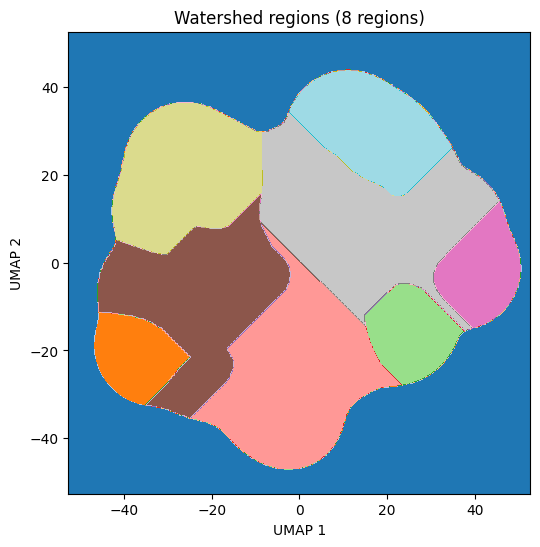

In [7]:
artifacts = load_watershed_artifacts(str(WSHED_PATH))
wshed_raw = hdf5storage.loadmat(str(WSHED_PATH))

LL = np.asarray(wshed_raw["LL"])
xx = artifacts["xx"].squeeze()
extent = artifacts["extent"]
wbounds = artifacts["wbounds"]

region_ids = sorted(int(r) for r in np.unique(LL) if r > 0)
print(f"{len(region_ids)} regions found in {WSHED_PATH.name}: {region_ids}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(LL, origin='lower', extent=extent, cmap='tab20')
ax.set_title(f"Watershed regions ({len(region_ids)} regions)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.show()

## 7.&nbsp; Assign each row of `df_nat` to a region

Same alignment logic as the "Region Timeline" section of
`Ethogram_Generation_Metabolism.ipynb`: `mmpy.findWatershedRegions` concatenates every
dataset's embeddings in whatever order `glob.glob` returned them (filesystem-dependent,
**not** alphabetical), but the true per-dataset order and block lengths are recorded in
the watershed file itself as `zValNames`/`zValLens`. We use those to slice out each
dataset's own `watershedRegions` block, then match rows by real timestamp (via each
dataset's `outputStatistics.keptIdx`, indexed into the same `real_timestamps` array
Section 5 already loaded into `real_timestamps_by_source` &mdash; not re-read here).

In [8]:
watershedRegions_full = wshed_raw["watershedRegions"].flatten().astype(float)
zval_names = [str(np.asarray(n).ravel()[0]) for n in wshed_raw["zValNames"].flatten()]
zval_lens = wshed_raw["zValLens"].flatten().astype(int)
zval_offsets = np.cumsum([0] + zval_lens[:-1].tolist())

source_id_blocks = {}
for name, length, offset in zip(zval_names, zval_lens, zval_offsets):
    stem = name[: -len("_pcaModes")] if name.endswith("_pcaModes") else name
    source_id_blocks[stem] = (offset, length)

df_nat["region"] = np.nan

for key in dataset_keys:
    source_id = _source_id(key)
    stats_file = PROJECTIONS_DIR / f"{source_id}_pcaModes_uVals_outputStatistics.pkl"

    with open(stats_file, "rb") as hfile:
        outputStatistics = pickle.load(hfile)

    keptIdx = np.asarray(outputStatistics.keptIdx).astype(int).ravel()
    # Reuse the full real_timestamps array Section 5 already loaded from this dataset's own
    # *_pcaModes.mat (and used, unfiltered, as df_nat's row set) instead of re-reading the
    # .mat file -- indexing it with keptIdx exactly mirrors what findEmbeddings did.
    real_ts = real_timestamps_by_source[source_id][keptIdx]

    offset, length = source_id_blocks[source_id]
    assert length == len(keptIdx), (
        f"keptIdx length ({len(keptIdx)}) doesn't match the watershed block length ({length}) "
        f"for {source_id}; the wshed file may be stale relative to the Projections folder."
    )
    region_classification = watershedRegions_full[offset : offset + length]

    ts_to_region = dict(zip(real_ts, region_classification))
    mask_source = df_nat["source_id"] == source_id
    df_nat.loc[mask_source, "region"] = df_nat.loc[mask_source, "real_timestamp"].map(ts_to_region)

n_before = len(df_nat)
df_nat = df_nat.dropna(subset=["region"])
df_nat["region"] = df_nat["region"].astype(int)
print(f"Assigned a region to {len(df_nat)}/{n_before} rows.")

# By construction (Section 5 built df_nat's row set directly from each dataset's own
# real_timestamps, and ts_to_region's keys are exactly real_timestamps[keptIdx], a subset of
# that same array), every kept point is now GUARANTEED to find a matching df_nat row -- this
# is no longer a lucky coincidence dependent on independently-reproduced interpolate/dropna
# row sets happening to line up by timestamp. A failure here now points to a real bug (e.g. a
# stale wshed file relative to Projections/, or a source_id_blocks slicing error), not to
# preprocessing drift.
assert len(df_nat) == len(watershedRegions_full), (
    f"df_nat ({len(df_nat)}) and the watershed's point count ({len(watershedRegions_full)}) "
    "should match exactly -- every embedded point should map back to exactly one row."
)

Assigned a region to 16498/19894 rows.


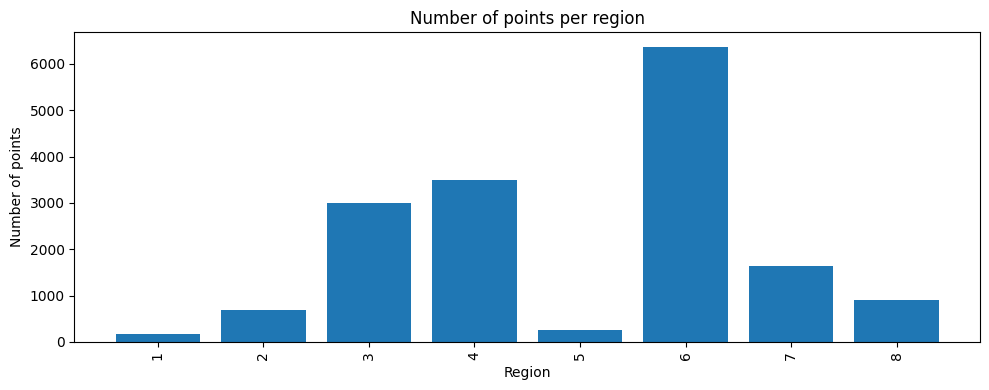

In [9]:
# Sanity check: number of points per region should match the watershed file's own counts
counts = df_nat["region"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(counts.index, counts.values)
ax.set_xlabel("Region")
ax.set_ylabel("Number of points")
ax.set_title("Number of points per region")
ax.set_xticks(counts.index)
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

## 8.&nbsp; Compute per-region means

If `pipeline_config.pkl` was found (Section 2), it's the authoritative record of which raw
columns this project's PCA/UMAP was actually built from, so fields are selected from it
directly (asserting the expected columns exist in `df_nat`, rather than silently trusting the
cache). Otherwise fields are inferred from whichever columns happen to be present in
`df_nat`, with each choice printed explicitly so it's auditable. Either way: single-IHL
datasets have `co2_L`/`co2_R` and (when `only_ambT=True`) a `Tamb` column, while whole-hive
datasets have all 4 CO&#8322; sensors (`co2_UL`/`co2_UR`/`co2_LL`/`co2_LR`) and, when
`only_ambT=False`, a 64- or 128-sensor thermal grid (`t00...`/`t000...`) instead of `Tamb`.
Mean CO&#8322; is the average of whichever CO&#8322; sensors are present; activity is stored
as a 0-1 fraction and converted to a percentage; relative humidity is used as-is. For
temperature, the field is only ever called **"Ambient temperature"** when the UMAP was
actually trained on `Tamb` (a proper ambient-temperature estimate via `extractAmbientTemp`)
&mdash; when it wasn't (e.g. a whole-hive run with `only_ambT=False`, like `WholeHive`, whose
UMAP never saw `Tamb` at all), the field is instead labeled **"Average hive temperature"**
and computed as the mean of the 64/128 raw per-sensor thermal-grid columns the UMAP actually
used &mdash; a different, noisier quantity (it also picks up bee bodies/hive structure), so
the plot's title should never claim it's ambient temperature.

In [10]:
FIELDS = {}

co2_channels_whole = ["co2_UL", "co2_UR", "co2_LL", "co2_LR"]
co2_channels_ihl = ["co2_L", "co2_R"]
temp_sensor_cols = sorted(c for c in df_nat.columns if re.match(r"^t\d+$", c))

if pipeline_config is not None:
    # Authoritative path: pipeline_config.pkl records exactly which raw columns this project's
    # PCA/UMAP was built from, so use that instead of guessing from whatever happens to be in
    # the (shared, mutable) Intermediate_Results cache -- and fail loudly if the cache turns out
    # to be missing something the config says should be there, rather than silently skip it.
    co2_channels = co2_channels_whole if pipeline_config.get("whole_hive", False) else co2_channels_ihl
    missing = [c for c in co2_channels if c not in df_nat.columns]
    assert not missing, (
        f"pipeline_config.pkl says whole_hive={pipeline_config.get('whole_hive')}, so this "
        f"project's CO2 input should be {co2_channels}, but {missing} are missing from df_nat "
        f"-- the Intermediate_Results cache looks stale/incomplete for this project."
    )
    df_nat["co2_mean"] = df_nat[co2_channels].mean(axis=1)
    FIELDS["Mean CO2 (ppm)"] = ("co2_mean", "viridis")

    assert "rel_humid" in df_nat.columns, "pipeline_config.pkl expects 'rel_humid', but it's missing from df_nat."
    FIELDS["Relative humidity (%)"] = ("rel_humid", "viridis")

    if pipeline_config.get("include_activity", True):
        assert "activity" in df_nat.columns, (
            "pipeline_config.pkl says include_activity=True, but 'activity' is missing from df_nat."
        )
        df_nat["activity_pct"] = df_nat["activity"] * 100.0
        FIELDS["Activity (%)"] = ("activity_pct", "viridis")
    else:
        print("pipeline_config.pkl: include_activity=False -- skipping the activity heatmap.")

    if not pipeline_config.get("include_temperature", True):
        print("pipeline_config.pkl: include_temperature=False -- skipping the temperature heatmap.")
    else:
        if "only_ambT" in pipeline_config:
            only_ambT = pipeline_config["only_ambT"]
        else:
            # Older Ethogram_Generation_Metabolism.ipynb configs never recorded this key
            # because that notebook always used only_amb_T=True -- its absence means True,
            # not the False a bare .get(..., False) would assume.
            only_ambT = True
            print("pipeline_config.pkl has no 'only_ambT' key -- inferring only_ambT=True (Metabolism-notebook config).")

        if only_ambT:
            # The UMAP was actually trained on Tamb -- a proper ambient-temperature estimate.
            assert "Tamb" in df_nat.columns, "only_ambT=True, but 'Tamb' is missing from df_nat."
            FIELDS["Ambient temperature (C)"] = ("Tamb", "viridis")
        else:
            # The UMAP was trained on the per-sensor thermal grid, NOT Tamb -- so don't label
            # this "ambient temperature" (that's a different, dedicated quantity this run never
            # saw). It's the mean of the 64/128 raw thermal-grid sensors instead, a noisier
            # quantity that also picks up bee bodies/hive structure.
            assert temp_sensor_cols, (
                "only_ambT=False, but no per-sensor temperature columns ('tNN...') were found in df_nat."
            )
            df_nat["Tamb_mean"] = df_nat[temp_sensor_cols].mean(axis=1)
            FIELDS["Average hive temperature (C)"] = ("Tamb_mean", "viridis")
else:
    # Heuristic fallback for projects with no pipeline_config.pkl (see Section 2) -- infer
    # fields from whatever columns are present, explicitly printing what was found/used for
    # each so it's at least auditable rather than silent.
    print("No pipeline_config.pkl -- inferring fields from df_nat's columns:")

    if set(co2_channels_whole).issubset(df_nat.columns):
        print(f"  CO2: using {co2_channels_whole} (whole-hive, 4 sensors)")
        df_nat["co2_mean"] = df_nat[co2_channels_whole].mean(axis=1)
        FIELDS["Mean CO2 (ppm)"] = ("co2_mean", "viridis")
    elif set(co2_channels_ihl).issubset(df_nat.columns):
        print(f"  CO2: using {co2_channels_ihl} (single-IHL, 2 sensors)")
        df_nat["co2_mean"] = df_nat[co2_channels_ihl].mean(axis=1)
        FIELDS["Mean CO2 (ppm)"] = ("co2_mean", "viridis")
    else:
        print("  CO2: no recognized CO2 columns found -- skipping the CO2 heatmap.")

    if "rel_humid" in df_nat.columns:
        print("  Humidity: using 'rel_humid'")
        FIELDS["Relative humidity (%)"] = ("rel_humid", "viridis")
    else:
        print("  Humidity: no 'rel_humid' column found -- skipping the humidity heatmap.")

    if "activity" in df_nat.columns:
        print("  Activity: using 'activity'")
        df_nat["activity_pct"] = df_nat["activity"] * 100.0
        FIELDS["Activity (%)"] = ("activity_pct", "viridis")
    else:
        print("  Activity: no 'activity' column found -- skipping the activity heatmap.")

    if "Tamb" in df_nat.columns:
        # Tamb is a proper ambient-temperature estimate (via extractAmbientTemp), not just a
        # raw sensor average -- prefer it whenever present, and only then call the field
        # "ambient temperature" (the UMAP was actually trained on this quantity).
        print("  Temperature: using 'Tamb'")
        FIELDS["Ambient temperature (C)"] = ("Tamb", "viridis")
    elif temp_sensor_cols:
        # No 'Tamb' column at all -- the UMAP was trained on the per-sensor thermal grid, not
        # on ambient temperature, so label this field for what it actually is: the mean of the
        # raw per-sensor grid (a different, noisier physical quantity that also picks up bee
        # bodies/hive structure), not "ambient temperature".
        print(f"  Temperature: no 'Tamb' column -- falling back to mean of {len(temp_sensor_cols)} 'tNN...' sensor columns")
        df_nat["Tamb_mean"] = df_nat[temp_sensor_cols].mean(axis=1)
        FIELDS["Average hive temperature (C)"] = ("Tamb_mean", "viridis")
    else:
        print("  Temperature: no temperature columns found -- skipping the temperature heatmap.")

region_means = {
    title: df_nat.groupby("region")[col].mean()
    for title, (col, _cmap) in FIELDS.items()
}

for title, means in region_means.items():
    print(f"\n{title}:")
    print(means)

pipeline_config.pkl: include_temperature=False -- skipping the temperature heatmap.

Mean CO2 (ppm):
region
1    1640.050000
2    6905.073007
3    3932.058091
4    3245.507703
5    1636.059717
6    4788.397258
7    1643.747339
8    1632.613036
Name: co2_mean, dtype: float64

Relative humidity (%):
region
1    44.263551
2    61.931062
3    51.695307
4    51.280735
5    48.147467
6    53.999656
7    45.940455
8    54.957390
Name: rel_humid, dtype: float64

Activity (%):
region
1     2.728856
2     5.495197
3     7.308832
4     8.389662
5     4.018391
6    13.311356
7     6.498111
8    16.527232
Name: activity_pct, dtype: float64


## 9.&nbsp; Most meaningful timeframe per region (from wavelet coefficients)

`findEmbeddings(..., saveWaveletAmps=True)` (see `motionmapperpy/motionmapper.py`) now
saves each dataset's Morlet wavelet amplitude spectrum &mdash; one amplitude-vs-period
curve per PCA mode, per kept timepoint &mdash; into its own
`Projections/{source_id}_pcaModes_uVals_outputStatistics.pkl`, alongside the period
axis (`waveletFrequencies`, log-spaced between `parameters.minF` and `parameters.maxF`).
Reusing `_load_wavelet_data`/`_characteristic_period_minutes` from `umap_interp_utils.py`
(already used there to size a raw-data window around a clicked UMAP point from its own
wavelet spectrum), we aggregate these *per point* spectra into one average spectrum
*per region*, then take that spectrum's amplitude-weighted mean period as the region's
characteristic ("most meaningful") timescale. This runs before the heatmap grid
(Section 10) so that timescale can be plotted there as one more panel alongside the
sensor fields.

A dataset's wavelet amplitude rows share the exact same order as its watershed-region
block (both are computed downstream of the same per-dataset, order-preserving
wavelet &rarr; UMAP-embed &rarr; watershed-assign steps), so no timestamp matching is
needed here &mdash; row *j* of `waveletAmplitudes` is row *j* of that dataset's region
block.

In [11]:
from umap_interp_utils import _load_wavelet_data, _characteristic_period_minutes

sum_spectrum = {}    # region_id -> running sum of mode-summed amplitude spectra
count_spectrum = {}  # region_id -> number of points contributing
wavelet_frequencies = None
missing_wavelets = []

for key in dataset_keys:
    source_id = _source_id(key)
    amps, freqs = _load_wavelet_data(source_id, PROJECTIONS_DIR)
    if amps is None:
        missing_wavelets.append(source_id)
        continue

    if wavelet_frequencies is None:
        wavelet_frequencies = freqs
    num_periods = freqs.shape[0]

    offset, length = source_id_blocks[source_id]
    assert amps.shape[0] == length, (
        f"waveletAmplitudes row count ({amps.shape[0]}) doesn't match the watershed block "
        f"length ({length}) for {source_id}; the wshed file may be stale relative to the "
        f"Projections folder."
    )
    region_classification = watershedRegions_full[offset : offset + length].astype(int)
    mode_summed = amps.reshape(length, -1, num_periods).sum(axis=1)  # (length, numPeriods)

    for rid in np.unique(region_classification):
        if rid <= 0:
            continue
        mask = region_classification == rid
        sum_spectrum[rid] = sum_spectrum.get(rid, 0.0) + mode_summed[mask].sum(axis=0)
        count_spectrum[rid] = count_spectrum.get(rid, 0) + int(mask.sum())

if missing_wavelets:
    print(
        f"No saved waveletAmplitudes for: {missing_wavelets} (skipped -- re-run "
        f"findEmbeddings(..., saveWaveletAmps=True) for these datasets to include them)"
    )

average_spectrum = {rid: spec / count_spectrum[rid] for rid, spec in sum_spectrum.items()}
period_hours = (1.0 / wavelet_frequencies) / 3600.0

region_period_hours = pd.Series(
    {
        rid: _characteristic_period_minutes(spec, wavelet_frequencies) / 60.0
        for rid, spec in average_spectrum.items()
    },
    name="characteristic_period_hours",
).sort_index()
print(region_period_hours)

1     8.572027
2     6.158926
3     6.736360
4     8.275709
5     7.884773
6     7.471201
7    10.264780
8     9.782037
Name: characteristic_period_hours, dtype: float64


## 10.&nbsp; Heatmaps over the watershed regions

Each region is filled with its mean value for the given field (regions with no
assigned points are left blank), region boundaries are traced in black, and region
numbers are annotated at each region's centroid &mdash; the same numbering as in
`UMAP/zWshed15.png`. Alongside the sensor fields from Section 8, this also plots the
amplitude-weighted mean wavelet period from Section 9 as one more panel ("most
meaningful timeframe").

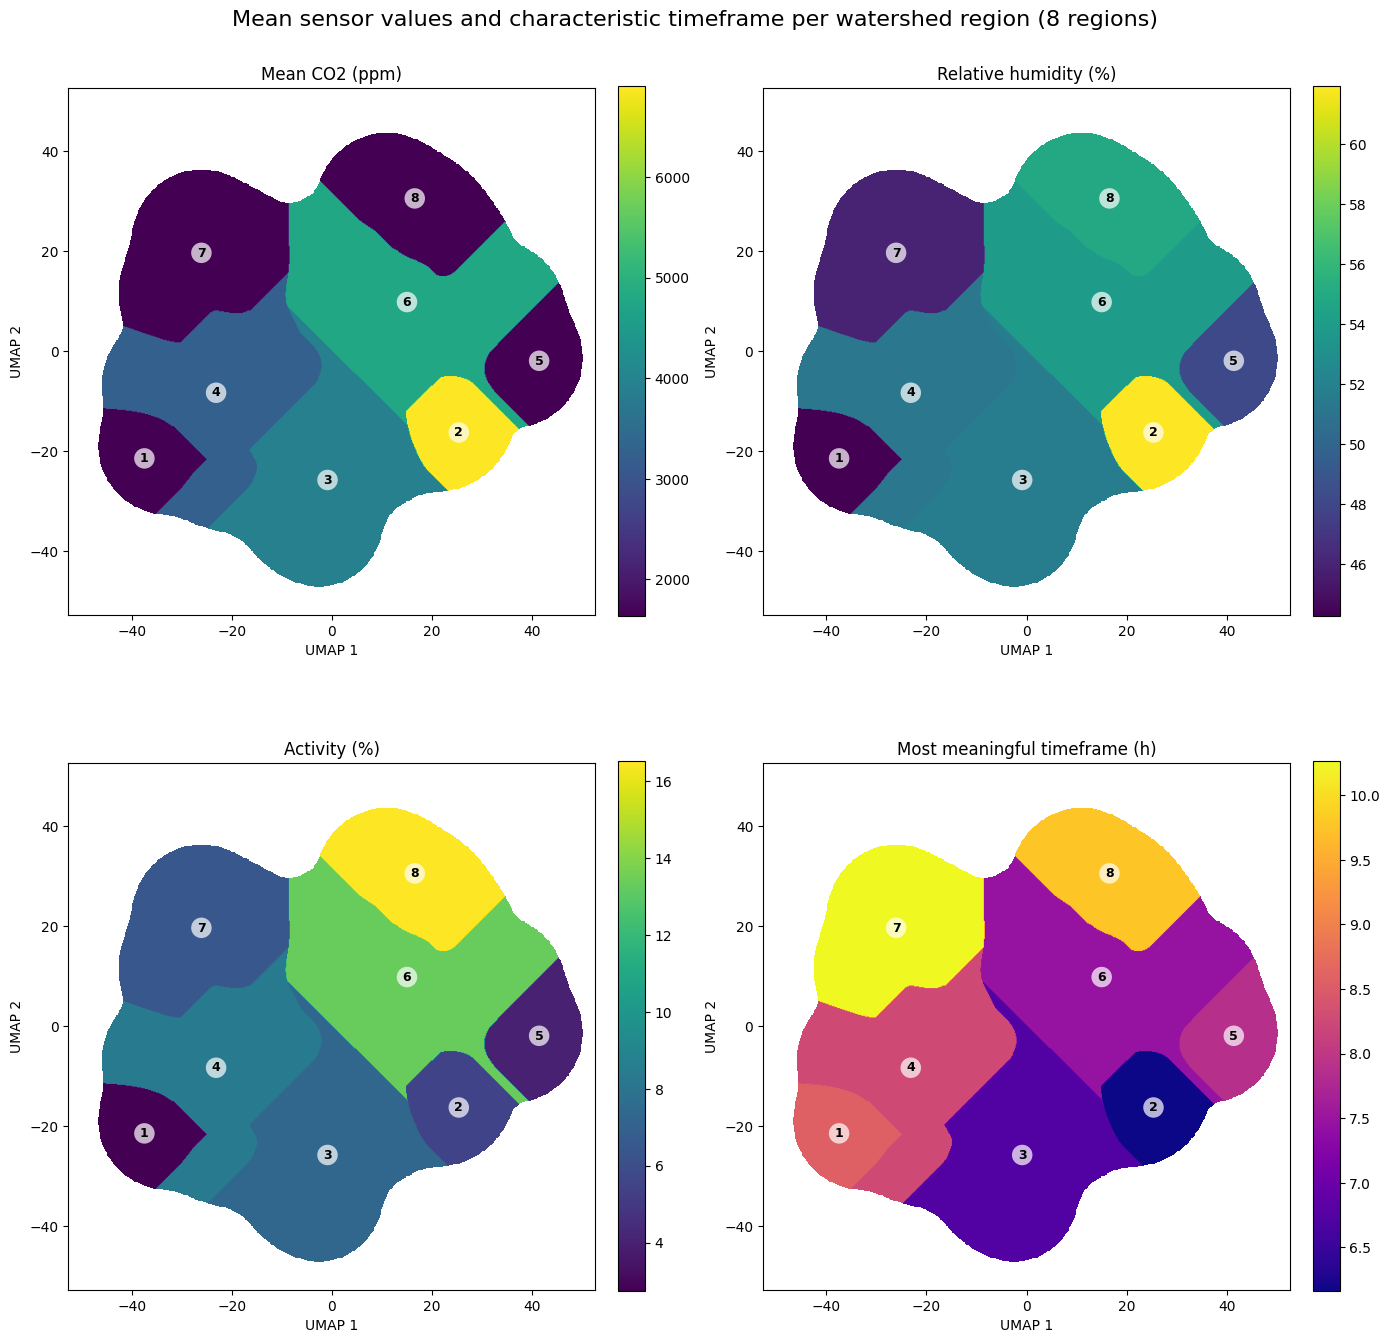

In [12]:
def region_value_map(LL, means):
    """Paint each pixel of the label image LL with its region's mean value (NaN elsewhere)."""
    H = np.full(LL.shape, np.nan)
    for region_id, value in means.items():
        H[LL == region_id] = value
    return H


def plot_region_heatmap(ax, LL, means, xx, wbounds, title, cmap):
    extent = (xx.min(), xx.max(), xx.min(), xx.max())
    H = region_value_map(LL, means)

    im = ax.imshow(H, origin="lower", extent=extent, cmap=cmap, aspect="equal")

    for boundary in wbounds:
        boundary = np.asarray(boundary, dtype=float)
        if boundary.ndim == 2 and boundary.shape[1] == 2:
            ax.plot(boundary[:, 0], boundary[:, 1], color="black", linewidth=0.6, alpha=0.6)

    for region_id in means.index:
        ys, xs = np.where(LL == region_id)
        if xs.size == 0:
            continue
        cx = xx[int(round(xs.mean()))]
        cy = xx[int(round(ys.mean()))]
        ax.text(
            cx, cy, str(int(region_id)),
            ha="center", va="center", fontsize=9, fontweight="bold", color="black",
            bbox=dict(boxstyle="circle", fc="white", alpha=0.7, ec="none"),
        )

    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    fig = ax.get_figure()
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


# Panels to plot: the sensor fields from Section 8, plus the amplitude-weighted mean
# wavelet period per region from Section 9 ("most meaningful timeframe").
panels = dict(region_means)
panel_cmaps = {title: cmap for title, (_col, cmap) in FIELDS.items()}
panels["Most meaningful timeframe (h)"] = region_period_hours
panel_cmaps["Most meaningful timeframe (h)"] = "plasma"

# Grid sized to however many panels ended up available -- e.g. a whole-hive run with
# include_activity=False and no Tamb column has fewer sensor fields.
n_panels = len(panels)
ncols = 2
nrows = int(np.ceil(n_panels / ncols)) if n_panels else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 7 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax, title in zip(axes_flat, panels):
    plot_region_heatmap(ax, LL, panels[title], xx, wbounds, title, panel_cmaps[title])

for ax in axes_flat[n_panels:]:
    ax.axis("off")

fig.suptitle(
    f"Mean sensor values and characteristic timeframe per watershed region ({len(region_ids)} regions)",
    fontsize=16,
)
plt.tight_layout()

# Save figure to project directory
fig.savefig(PROJECT_DIR / "region_field_heatmaps.png", dpi=300)
plt.show()

## 11.&nbsp; Average wavelet amplitude spectrum per region

One small panel per region: its average (mode-summed) wavelet amplitude spectrum, with
a dashed line marking the amplitude-weighted mean period &mdash; the same value plotted
as the "most meaningful timeframe" heatmap panel in Section 10 above.

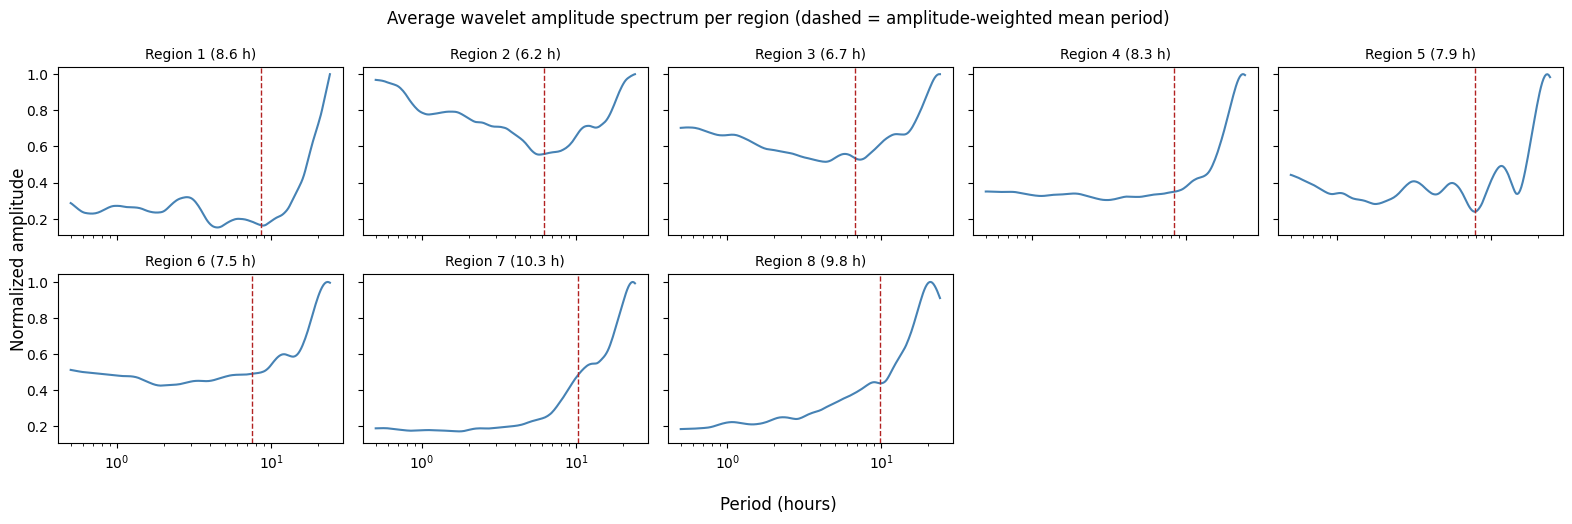

In [13]:
# One small panel per region: its average (mode-summed) wavelet amplitude spectrum, with a
# dashed line marking the amplitude-weighted mean period -- i.e. where that curve's mass is
# centered, this region's "most meaningful timeframe".
region_ids_wav = sorted(average_spectrum.keys())
ncols = 5
nrows = int(np.ceil(len(region_ids_wav) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.6 * nrows), sharex=True, sharey=True)
axes_flat = np.atleast_1d(axes).flatten()

for ax, rid in zip(axes_flat, region_ids_wav):
    spectrum = average_spectrum[rid]
    ax.plot(period_hours, spectrum / spectrum.max(), color="steelblue", linewidth=1.5)
    ax.axvline(region_period_hours[rid], color="firebrick", linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_title(f"Region {rid} ({region_period_hours[rid]:.1f} h)", fontsize=10)

for ax in axes_flat[len(region_ids_wav):]:
    ax.axis("off")

fig.supxlabel("Period (hours)")
fig.supylabel("Normalized amplitude")
fig.suptitle("Average wavelet amplitude spectrum per region (dashed = amplitude-weighted mean period)")
plt.tight_layout()
plt.show()